# Визуализация и анализ товарных эмбеддингов

Этот ноутбук исследует геометрию пространства готовых товарных эмбеддингов перед кластеризацией. В отличие от первоначальной версии, анализ проводится на стратифицированной выборке из 20 000 товаров, а не на 1 000 объектах.

Выборка формируется по всем 122 категориям каталога. Это снижает влияние крупнейших категорий на PCA и распределения расстояний. Для каждой категории выбирается примерно одинаковое число товаров, после чего сохраняется состав выборки по исходным строкам Parquet.

Работа состоит из следующих этапов:

1. Формирование и декодирование стратифицированной выборки эмбеддингов.
2. Проверка размерности, диапазона значений и норм векторов.
3. Визуализация пространства в двух и трёх главных компонентах PCA.
4. Анализ распределения компонент и объяснённой дисперсии.
5. Анализ косинусных расстояний и сравнение товаров внутри и между категориями.

Ноутбук не обучает модель и не подбирает параметры кластеризации. Его задача — проверить, что пространство признаков достаточно содержательно для следующих этапов: K-Means, HDBSCAN и DeepCluster.


## 1. Настройки и доступ к данным

Полный датасет содержит около 4,79 млн товаров. Эмбеддинги в Parquet хранятся в бинарном виде, поэтому читаем файл порциями и декодируем только выбранные строки. Это позволяет выполнить анализ на локальном Mac без загрузки всего каталога в оперативную память.


In [1]:
import os
import json
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
ASSETS = Path(os.environ.get("COURSEWORK_ASSETS", str(ROOT))).expanduser()
DATA_PATH = ASSETS / "data/raw/dataset-electronics-5M.parquet"
OUTPUT_DIR = ROOT / "results" / "03_embeddings_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
TARGET_SIZE = 20_000
DISTANCE_SAMPLE_SIZE = 2_000
PAIR_SAMPLES_PER_CATEGORY = 1_000
PCA_COMPONENTS = 128
PURPLE = "#6C63FF"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Не найден {DATA_PATH}. Проверьте COURSEWORK_ASSETS.")

plt.rcParams.update({"figure.figsize": (12, 7), "font.size": 11, "axes.spines.top": False, "axes.spines.right": False})
print("Датасет:", DATA_PATH)
print("Размер выборки:", TARGET_SIZE)
print("Папка результатов:", OUTPUT_DIR.relative_to(ROOT))


Датасет: /tmp/coursework-assets/data/raw/dataset-electronics-5M.parquet
Размер выборки: 20000
Папка результатов: results/03_embeddings_visualization


## 2. Стратифицированная выборка

Сначала читается только `category_id`, чтобы определить число товаров в каждой категории. Затем из каждой категории выбирается почти одинаковое количество строк. Две самые редкие категории содержат меньше целевой квоты, поэтому они входят в выборку целиком, а освободившиеся места равномерно распределяются между остальными категориями с фиксированным `seed`.

Такой способ не делает выборку похожей на естественное распределение каталога. Он нужен именно для исследования: PCA и графики получают вклад от всех категорий, а не преимущественно от нескольких самых крупных.


In [2]:
parquet_file = pq.ParquetFile(DATA_PATH)
category_counts = {}

for batch in parquet_file.iter_batches(batch_size=100_000, columns=["category_id"]):
    values, counts = np.unique(batch.column(0).to_numpy(), return_counts=True)
    for category, count in zip(values, counts):
        category_counts[category] = category_counts.get(category, 0) + int(count)

category_counts = pd.Series(category_counts).sort_index()
categories = category_counts.index.to_numpy()

if TARGET_SIZE < len(categories):
    raise ValueError("TARGET_SIZE должен быть не меньше числа категорий.")

base_per_category = TARGET_SIZE // len(categories)
requested_per_category = category_counts.clip(upper=base_per_category).astype(int)
remaining = TARGET_SIZE - int(requested_per_category.sum())
allocation_rng = np.random.default_rng(SEED)

while remaining > 0:
    capacity = category_counts - requested_per_category
    eligible = capacity[capacity > 0].index.to_numpy()
    if len(eligible) == 0:
        raise ValueError("В датасете недостаточно объектов для заданного размера выборки.")
    selected = eligible if remaining >= len(eligible) else allocation_rng.choice(eligible, size=remaining, replace=False)
    requested_per_category.loc[selected] += 1
    remaining -= len(selected)

reservoirs = {category: [] for category in categories}
rng = np.random.default_rng(SEED)
seen_per_category = {category: 0 for category in categories}
row_offset = 0

for batch in parquet_file.iter_batches(batch_size=100_000, columns=["category_id"]):
    batch_categories = batch.column(0).to_numpy()
    for position, category in enumerate(batch_categories):
        seen_per_category[category] += 1
        reservoir = reservoirs[category]
        limit = int(requested_per_category.loc[category])
        if len(reservoir) < limit:
            reservoir.append(row_offset + position)
        else:
            replacement = rng.integers(seen_per_category[category])
            if replacement < limit:
                reservoir[replacement] = row_offset + position
    row_offset += len(batch_categories)

sample_indices = np.sort(np.concatenate([np.asarray(reservoirs[category]) for category in categories]))

print("Всего товаров:", int(category_counts.sum()))
print("Категорий:", len(categories))
print("Товаров в выборке:", len(sample_indices))
print("Минимум на категорию:", int(requested_per_category.min()))
print("Максимум на категорию:", int(requested_per_category.max()))


Всего товаров: 4793821
Категорий: 122
Товаров в выборке: 20000
Минимум на категорию: 5
Максимум на категорию: 167


Далее выбираются только строки с нужными номерами и декодируется поле `embedding`. Формат проверен в предыдущих ноутбуках: каждая запись содержит два служебных байта, затем 312 чисел `float64`, разделённых десятибайтными блоками. После декодирования данные приводятся к `float32`, что достаточно для PCA и расчёта расстояний.


In [3]:
def decode_embedding(data):
    data = bytes(data)
    if len(data) != 3122:
        raise ValueError(f"Неожиданный размер embedding: {len(data)}")
    values = np.empty(312, dtype=np.float32)
    for index in range(312):
        start = 2 + index * 10
        values[index] = np.frombuffer(data[start:start + 8], dtype="<f8")[0]
    return values

selected = set(sample_indices.tolist())
embeddings_parts = []
categories_parts = []
rows_parts = []
offset = 0

for batch in parquet_file.iter_batches(batch_size=4096, columns=["embedding", "category_id"]):
    batch_size = batch.num_rows
    positions = [index for index in range(batch_size) if offset + index in selected]
    if positions:
        embedding_column = batch.column("embedding")
        category_column = batch.column("category_id")
        embeddings_parts.append(np.stack([decode_embedding(embedding_column[index].as_py()) for index in positions]))
        categories_parts.append(np.asarray([category_column[index].as_py() for index in positions], dtype=np.int64))
        rows_parts.append(np.asarray([offset + index for index in positions], dtype=np.int64))
    offset += batch_size

embeddings = np.concatenate(embeddings_parts).astype(np.float32, copy=False)
sample_categories = np.concatenate(categories_parts)
sample_rows = np.concatenate(rows_parts)

if embeddings.shape != (TARGET_SIZE, 312):
    raise ValueError(f"Получен неверный размер: {embeddings.shape}")
if not np.isfinite(embeddings).all():
    raise ValueError("В эмбеддингах найдены NaN или Inf")

manifest = pd.DataFrame({"source_row": sample_rows, "category_id": sample_categories})
manifest.to_csv(OUTPUT_DIR / "sample_manifest.csv", index=False)
np.save(OUTPUT_DIR / "embeddings_20000.npy", embeddings)

print("Размер матрицы:", embeddings.shape)
print("Тип:", embeddings.dtype)
print("Использовано памяти, МБ:", round(embeddings.nbytes / 1024**2, 2))


Размер матрицы: (20000, 312)
Тип: float32
Использовано памяти, МБ: 23.8


## 3. Проверка числовых свойств

Перед визуализацией проверяем диапазон значений, нормы и нулевые векторы. Нулевые или нечисловые векторы сделали бы косинусные расстояния и нормализацию некорректными. Разброс норм также важен: для методов, основанных на евклидовом расстоянии, масштаб вектора влияет на результат.


In [4]:
norms = np.linalg.norm(embeddings, axis=1)
summary = pd.Series({
    "Товаров": len(embeddings),
    "Размерность": embeddings.shape[1],
    "Минимум": embeddings.min(),
    "Максимум": embeddings.max(),
    "Среднее": embeddings.mean(),
    "Стандартное отклонение": embeddings.std(),
    "Минимальная норма": norms.min(),
    "Максимальная норма": norms.max(),
    "Средняя норма": norms.mean(),
    "Нулевых векторов": int(np.sum(norms < 1e-6))
})
display(summary.to_frame("Значение"))


,Значение
Товаров,20000.000000
Размерность,312.000000
Минимум,-0.294922
Максимум,0.310547
Среднее,0.000309
Стандартное отклонение,0.056621
Минимальная норма,0.996107
Максимальная норма,1.004398
Средняя норма,1.000140
Нулевых векторов,0.000000


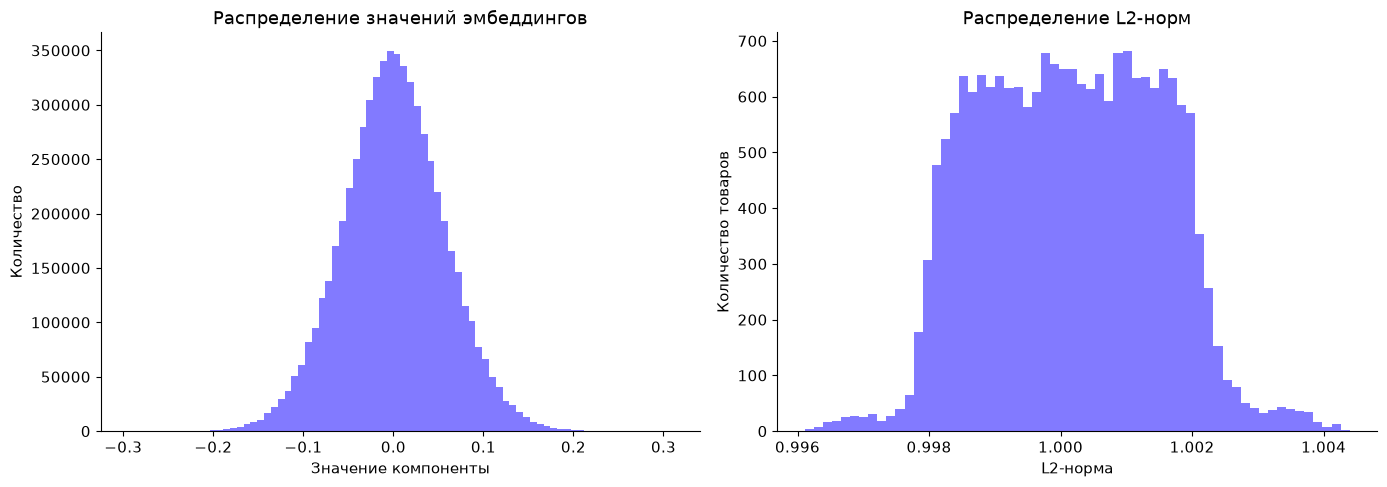

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(embeddings.ravel(), bins=80, color=PURPLE, alpha=0.85)
axes[0].set(title="Распределение значений эмбеддингов", xlabel="Значение компоненты", ylabel="Количество")
axes[1].hist(norms, bins=60, color=PURPLE, alpha=0.85)
axes[1].set(title="Распределение L2-норм", xlabel="L2-норма", ylabel="Количество товаров")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "values_and_norms.png", dpi=150)
plt.show()


## 4. PCA и визуализация пространства

PCA строится на всех 20 000 товарах. Двумерная и трёхмерная проекции нужны для качественного просмотра структуры, но не сохраняют всю информацию исходного 312-мерного пространства. Поэтому рядом строится график накопленной объяснённой дисперсии: он показывает, какую часть вариативности сохраняет заданное число компонент.


In [6]:
pca_2d = PCA(n_components=2, svd_solver="randomized", random_state=SEED)
embeddings_2d = pca_2d.fit_transform(embeddings)
pca_3d = PCA(n_components=3, svd_solver="randomized", random_state=SEED)
embeddings_3d = pca_3d.fit_transform(embeddings)
pca_variance = PCA(n_components=PCA_COMPONENTS, svd_solver="randomized", random_state=SEED)
pca_variance.fit(embeddings)
cumulative_variance = np.cumsum(pca_variance.explained_variance_ratio_)

print("PCA 2D, объяснённая дисперсия:", round(pca_2d.explained_variance_ratio_.sum() * 100, 2), "%")
print("PCA 3D, объяснённая дисперсия:", round(pca_3d.explained_variance_ratio_.sum() * 100, 2), "%")
print("PCA 128, объяснённая дисперсия:", round(cumulative_variance[-1] * 100, 2), "%")


PCA 2D, объяснённая дисперсия: 6.67 %
PCA 3D, объяснённая дисперсия: 9.11 %
PCA 128, объяснённая дисперсия: 98.52 %


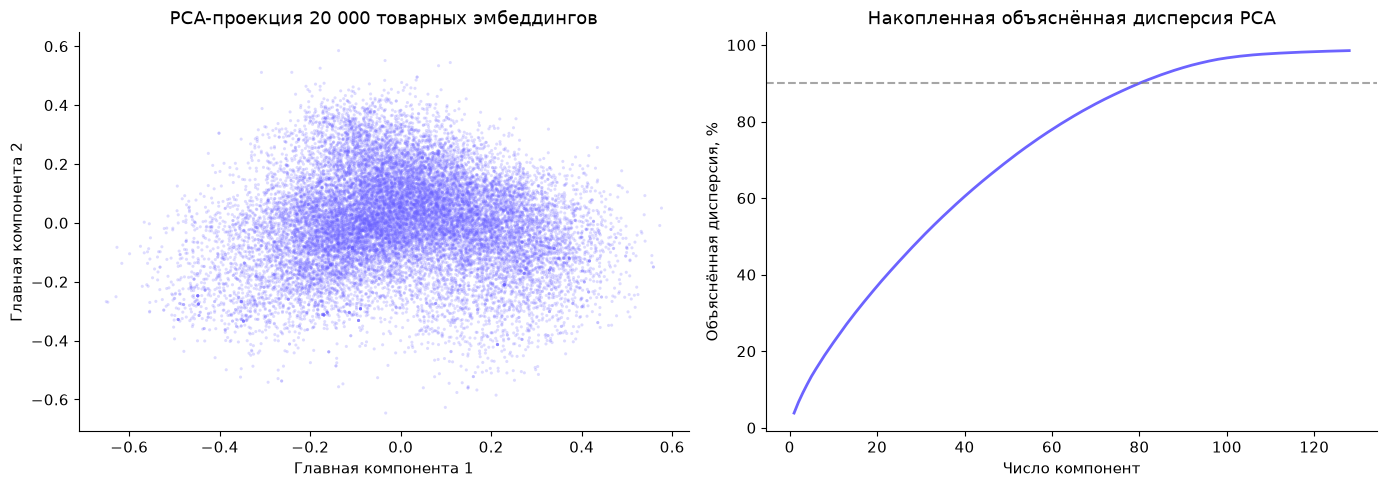

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=5, alpha=0.22, color=PURPLE, edgecolors="none")
axes[0].set(title="PCA-проекция 20 000 товарных эмбеддингов", xlabel="Главная компонента 1", ylabel="Главная компонента 2")
axes[1].plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance * 100, color=PURPLE, linewidth=2)
axes[1].axhline(90, color="grey", linestyle="--", alpha=0.7)
axes[1].set(title="Накопленная объяснённая дисперсия PCA", xlabel="Число компонент", ylabel="Объяснённая дисперсия, %")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "pca_2d_and_variance.png", dpi=150)
plt.show()


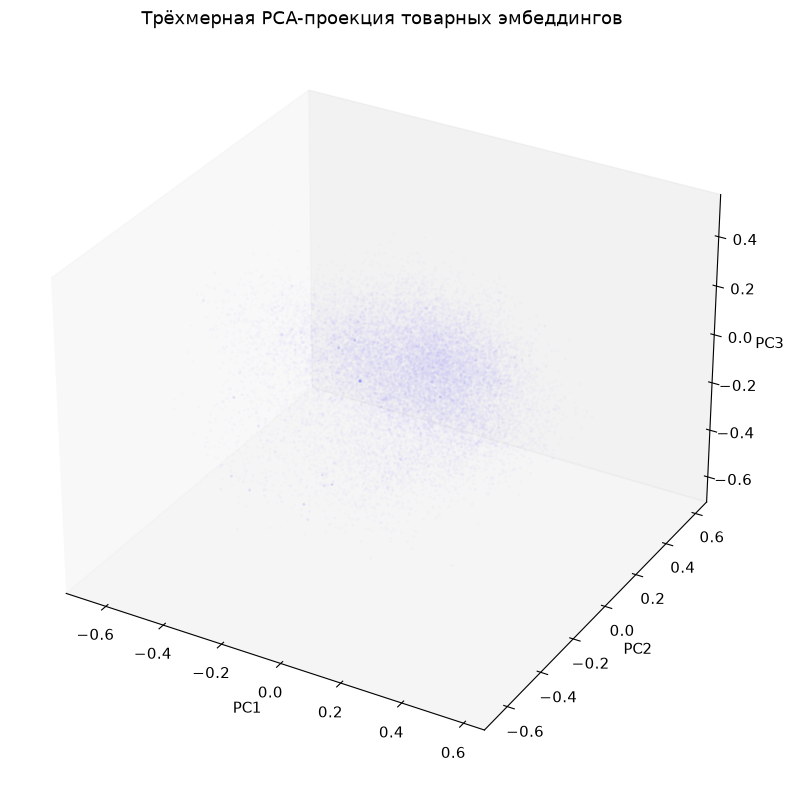

In [8]:
fig = plt.figure(figsize=(11, 8))
axis = fig.add_subplot(111, projection="3d")
axis.scatter(embeddings_3d[:, 0], embeddings_3d[:, 1], embeddings_3d[:, 2], s=4, alpha=0.16, color=PURPLE, edgecolors="none")
axis.set(title="Трёхмерная PCA-проекция товарных эмбеддингов", xlabel="PC1", ylabel="PC2", zlabel="PC3")
axis.grid(False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "pca_3d.png", dpi=150)
plt.show()


## 5. Косинусные расстояния и категориальный сигнал

Для полной матрицы расстояний между 20 000 товарами потребовалось бы 400 млн значений. Поэтому общее распределение косинусных расстояний оценивается на случайной подвыборке из 2 000 товаров. Это даёт 1 999 000 уникальных пар и достаточно устойчивую картину без лишнего расхода памяти.

Дополнительно сравниваются косинусные сходства внутри одной категории и между разными категориями. Это не метрика матчинга: товары одной категории не обязаны быть одинаковыми. Но если внутриклассовая близость в среднем выше межклассовой, эмбеддинги сохраняют хотя бы часть структуры товарного каталога.


In [9]:
rng = np.random.default_rng(SEED)
distance_indices = rng.choice(len(embeddings), size=DISTANCE_SAMPLE_SIZE, replace=False)
distance_embeddings = normalize(embeddings[distance_indices])
similarity_matrix = distance_embeddings @ distance_embeddings.T
upper_indices = np.triu_indices(DISTANCE_SAMPLE_SIZE, k=1)
cosine_distances = 1 - similarity_matrix[upper_indices]

distance_summary = pd.Series({
    "Товаров для расстояний": DISTANCE_SAMPLE_SIZE,
    "Уникальных пар": len(cosine_distances),
    "Среднее косинусное расстояние": cosine_distances.mean(),
    "Медиана": np.median(cosine_distances),
    "Минимум": cosine_distances.min(),
    "Максимум": cosine_distances.max()
})
display(distance_summary.to_frame("Значение"))


,Значение
Товаров для расстояний,2.000000e+03
Уникальных пар,1.999000e+06
Среднее косинусное расстояние,9.522247e-01
Медиана,9.585460e-01
Минимум,-3.576279e-07
Максимум,1.409929e+00


,count,mean,median,std
within_category,120948.0,0.2362,0.2180,0.1867
between_categories,120948.0,0.0475,0.0416,0.1122


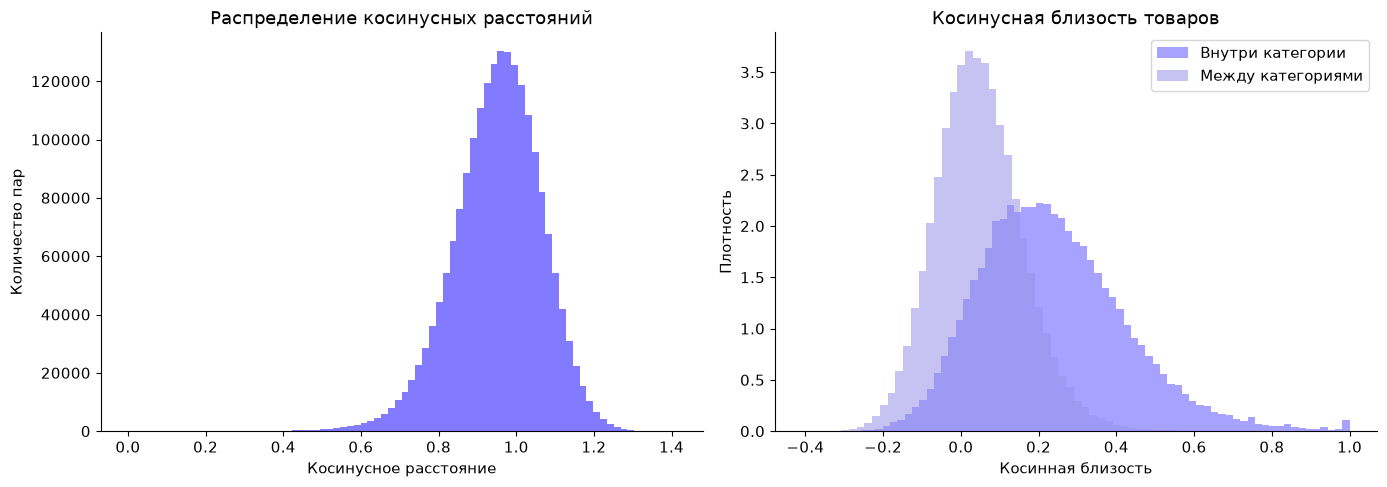

In [10]:
normalized_embeddings = normalize(embeddings)
within_similarities = []

for category in np.unique(sample_categories):
    category_indices = np.flatnonzero(sample_categories == category)
    first = rng.choice(category_indices, size=PAIR_SAMPLES_PER_CATEGORY, replace=True)
    second = rng.choice(category_indices, size=PAIR_SAMPLES_PER_CATEGORY, replace=True)
    valid = first != second
    within_similarities.extend(np.sum(normalized_embeddings[first[valid]] * normalized_embeddings[second[valid]], axis=1))

within_similarities = np.asarray(within_similarities)
between_parts = []
between_count = 0

while between_count < len(within_similarities):
    candidates = max(10_000, len(within_similarities) - between_count)
    first = rng.integers(0, len(embeddings), size=candidates)
    second = rng.integers(0, len(embeddings), size=candidates)
    valid = sample_categories[first] != sample_categories[second]
    values = np.sum(normalized_embeddings[first[valid]] * normalized_embeddings[second[valid]], axis=1)
    between_parts.append(values)
    between_count += len(values)

between_similarities = np.concatenate(between_parts)[:len(within_similarities)]

comparison = pd.DataFrame({
    "within_category": within_similarities,
    "between_categories": between_similarities
})
display(comparison.agg(["count", "mean", "median", "std"]).T.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(cosine_distances, bins=80, color=PURPLE, alpha=0.85)
axes[0].set(title="Распределение косинусных расстояний", xlabel="Косинусное расстояние", ylabel="Количество пар")
axes[1].hist(comparison["within_category"], bins=70, alpha=0.6, color=PURPLE, label="Внутри категории", density=True)
axes[1].hist(comparison["between_categories"], bins=70, alpha=0.55, color="#9793E8", label="Между категориями", density=True)
axes[1].set(title="Косинусная близость товаров", xlabel="Косинная близость", ylabel="Плотность")
axes[1].legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cosine_distances_and_category_signal.png", dpi=150)
plt.show()


## Вывод

Ноутбук формирует воспроизводимую стратифицированную выборку из 20 000 товарных эмбеддингов и проверяет её числовые и геометрические свойства. Все итоговые графики строятся на большем объёме данных, чем в первоначальной версии, а косинусные расстояния оцениваются по почти двум миллионам уникальных пар.

PCA-проекции нужны для визуального анализа, но не служат доказательством качества кластеров: первые две или три компоненты сохраняют лишь часть исходной вариативности. Для кластеризации и обучения DeepCluster далее используются исходные векторы либо многомерные PCA-признаки, а не 2D-проекция.

Сравнение близостей внутри и между категориями показывает только наличие категориального сигнала. Окончательная проверка качества эмбеддингов и DeepCluster выполняется отдельно через KNN на отложенной validation-выборке и, в перспективе, на размеченных парах товаров для задачи матчинга.
